In [12]:
import kagglehub
itsahmad_indoor_scenes_cvpr_2019_path = kagglehub.dataset_download('itsahmad/indoor-scenes-cvpr-2019')
# benjaminkz_places365_path = kagglehub.dataset_download('benjaminkz/places365')

print('Data source import complete.')

Data source import complete.


In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import time
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [13]:
# basePath = "/kaggle/input/indoor-scenes-cvpr-2019"
basePath = itsahmad_indoor_scenes_cvpr_2019_path

imgDir = os.path.join(basePath, "indoorCVPR_09", "Images")
trainLabelFile = os.path.join(basePath, "TrainImages.txt")
valLabelFile = os.path.join(basePath, "TestImages.txt")

print(trainLabelFile)

/Users/vishali/.cache/kagglehub/datasets/itsahmad/indoor-scenes-cvpr-2019/versions/1/TrainImages.txt


In [14]:
from collections import defaultdict


def read_image_list(file_path):
    with open(file_path, 'r') as f:
        return [line.strip() for line in f.readlines()]

train_images = read_image_list(trainLabelFile)
val_images = read_image_list(valLabelFile)
all_images = train_images + val_images

# Count class occurrences
class_counts = defaultdict(int)
for img_path in all_images:
    class_name = img_path.split('/')[0]
    class_counts[class_name] += 1

classes = sorted(class_counts.keys())

# Summary
print("Dataset Description:")
print(f"- Contains {len(classes)} classes: {classes[:5]}{'...' if len(classes) > 5 else ''}")
print(f"- Total images: {len(all_images)}")
print(f"- Class distribution:")
for cls in sorted(class_counts):
    print(f"  {cls:<20} : {class_counts[cls]}")

# (Optional) Show sample images
print("\nFirst 5 image files in Images folder:", os.listdir(imgDir)[:5])

Dataset Description:
- Contains 67 classes: ['airport_inside', 'artstudio', 'auditorium', 'bakery', 'bar']...
- Total images: 6700
- Class distribution:
  airport_inside       : 100
  artstudio            : 100
  auditorium           : 100
  bakery               : 100
  bar                  : 100
  bathroom             : 100
  bedroom              : 100
  bookstore            : 100
  bowling              : 100
  buffet               : 100
  casino               : 100
  children_room        : 100
  church_inside        : 100
  classroom            : 100
  cloister             : 100
  closet               : 100
  clothingstore        : 100
  computerroom         : 100
  concert_hall         : 100
  corridor             : 100
  deli                 : 100
  dentaloffice         : 100
  dining_room          : 100
  elevator             : 100
  fastfood_restaurant  : 100
  florist              : 100
  gameroom             : 100
  garage               : 100
  greenhouse           : 100
  groc

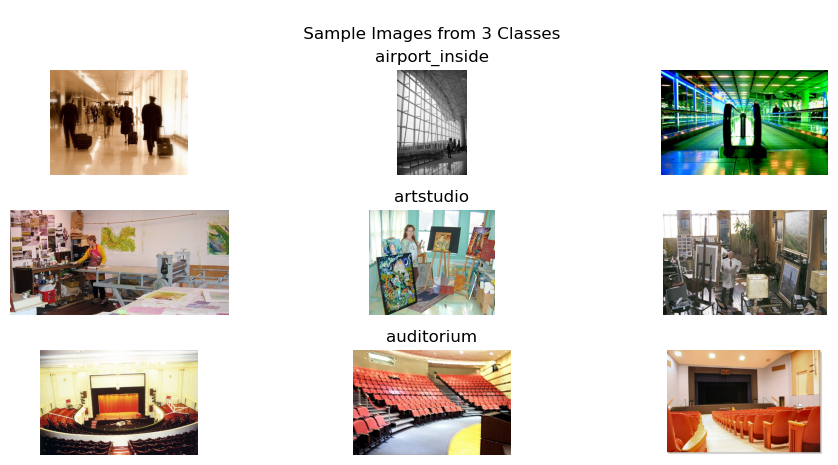

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from PIL import Image
import os

# Already defined earlier:
# - class_counts (dictionary: class_name → image count)
# - all_images (list of 'class_name/image.jpg')
# - imgDir = "/kaggle/input/indoor-scenes-cvpr-2019/indoorCVPR_09/Images"

# Sample visualization: 3 images each from 3 different classes
sample_classes = classes[:3]  # pick first 3 for display
plt.figure(figsize=(10, 5))
img_idx = 1

for cls in sample_classes:
    cls_images = [img for img in all_images if img.startswith(cls)][:3]
    for img_file in cls_images:
        img_path = os.path.join(imgDir, img_file)
        img = Image.open(img_path)
        plt.subplot(3, 3, img_idx)
        plt.imshow(img)
        plt.title(cls if img_idx % 3 == 2 else "")
        plt.axis('off')
        img_idx += 1

plt.suptitle("\n Sample Images from 3 Classes \n", y=0.92)
plt.tight_layout()
plt.show()


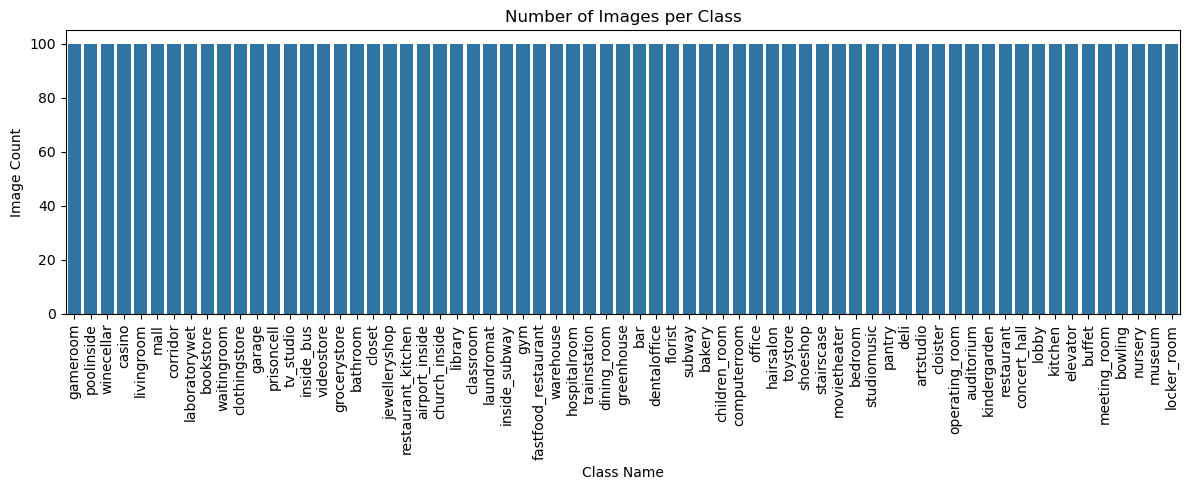

In [19]:
plt.figure(figsize=(12, 5))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
plt.xticks(rotation=90)
plt.title("Number of Images per Class")
plt.xlabel("Class Name")
plt.ylabel("Image Count")
plt.tight_layout()
plt.show()


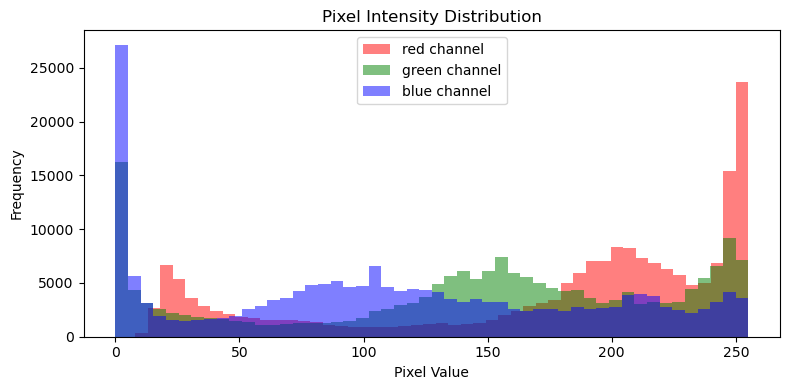

In [20]:
# Pick a sample image from first class
first_class = classes[0]
sample_img_path = next(img for img in all_images if img.startswith(first_class))
sample_img = np.array(Image.open(os.path.join(imgDir, sample_img_path)))

plt.figure(figsize=(8, 4))
colors = ['red', 'green', 'blue']
for i in range(3):
    plt.hist(sample_img[:, :, i].ravel(), bins=50, color=colors[i], alpha=0.5, label=f'{colors[i]} channel')
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


In [21]:
from torch.utils.data import Dataset
from PIL import Image
import os

class IndoorPlacesDataset(Dataset):
    def __init__(self, img_dir, label_file, transform=None):
        """
        Args:
            img_dir (str): Path to the 'Images' directory
            label_file (str): Path to TrainImages.txt or TestImages.txt
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.img_dir = img_dir
        self.transform = transform

        # Load image paths
        with open(label_file, 'r') as f:
            self.image_paths = [line.strip() for line in f.readlines()]

        # Extract unique class names from image paths
        self.classes = sorted({line.split('/')[0] for line in self.image_paths})
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        rel_path = self.image_paths[idx]  # e.g. 'bookstore/bookstore_003.jpg'
        label = self.class_to_idx[rel_path.split('/')[0]]
        img_path = os.path.join(self.img_dir, rel_path)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label


In [26]:
from torchvision import transforms
import random
from collections import defaultdict

train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Dataset & Dataloader
img_dir = basePath + "/indoorCVPR_09/Images"
train_file =  basePath + "/TrainImages.txt"
test_file =   basePath + "/TestImages.txt"

# train_dataset = IndoorPlacesDataset(img_dir, train_file, transform=train_transform)
# test_dataset = IndoorPlacesDataset(img_dir, test_file, transform=test_transform)

# train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
# test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)
with open(train_file, 'r') as f:
    train_lines = f.read().splitlines()

class_to_images = defaultdict(list)
for line in train_lines:
    class_name = line.split('/')[0]
    class_to_images[class_name].append(line)

# Shuffle and split per class
train_list, val_list = [], []

for cls, images in class_to_images.items():
    random.shuffle(images)
    split_idx = int(0.8 * len(images))
    train_list += images[:split_idx]
    val_list += images[split_idx:]

# Save to files
with open("train_split.txt", "w") as f:
    f.write("\n".join(train_list))
with open("val_split.txt", "w") as f:
    f.write("\n".join(val_list))

print("Train/Val split complete")
print(f"Train: {len(train_list)} images")
print(f"Val:   {len(val_list)} images")

train_dataset = IndoorPlacesDataset(img_dir, "train_split.txt", transform=train_transform)
val_dataset   = IndoorPlacesDataset(img_dir, "val_split.txt", transform=test_transform)
test_dataset  = IndoorPlacesDataset(img_dir, test_file, transform=test_transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

Train/Val split complete
Train: 4267 images
Val:   1093 images


In [ ]:
# /Users/vishali/.cache/kagglehub/datasets/itsahmad/indoor-scenes-cvpr-2019/versions/1/TrainImages.txt

In [28]:
import torch
import torch.nn as nn
import torch.nn.init as init

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride,
                               padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1,
                               padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.downsample = downsample

    def forward(self, x):
        identity = x
        
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        
        if self.downsample is not None:
            identity = self.downsample(x)
        
        out += identity
        out = self.relu(out)
        
        return out

class ResNet18(nn.Module):
    def __init__(self, num_classes=10, init_method='xavier'):  # Add init_method here
        super(ResNet18, self).__init__()
        
        self.in_channels = 64
        self.init_method = init_method  # Save method

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(64, 2)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 2, stride=2)
        self.layer4 = self._make_layer(512, 2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * BasicBlock.expansion, num_classes)

        self._initialize_weights(init_method)  # Call init function

    def _make_layer(self, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

        layers = [BasicBlock(self.in_channels, out_channels, stride, downsample)]
        self.in_channels = out_channels

        for _ in range(1, blocks):
            layers.append(BasicBlock(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

    def _initialize_weights(self, method='xavier'):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                init.xavier_normal_(m.weight)
            elif isinstance(m, nn.BatchNorm2d):
                init.constant_(m.weight, 1)
                init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                init.normal_(m.weight, 0, 0.01)
                init.constant_(m.bias, 0)



In [29]:
# training loop
early_stopping_threshold = 5
def train_model(model, train_loader, val_loader, criterion, optimizer,model_name_prefix, scheduler=None, num_epochs=25, device='cuda'):
    os.makedirs("saved_models", exist_ok=True)
    model = model.to(device)
    resnet_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'best_acc': 0}
    best_acc = 0.0
    for epoch in tqdm(range(num_epochs)):
        start_time = time.time()
        model.train()
        
        running_loss = 0.0
        correct = 0
        total = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        train_loss = running_loss / len(train_loader.dataset)
        train_acc = correct / total
        
        val_loss, val_acc, val_preds, val_labels = evaluate_model(model, val_loader, criterion, device)
        
        if scheduler:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_acc)
            else:
                scheduler.step()
        
        resnet_history['train_loss'].append(train_loss)
        resnet_history['val_loss'].append(val_loss)
        resnet_history['train_acc'].append(train_acc)
        resnet_history['val_acc'].append(val_acc)
        

        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            resnet_history['best_acc'] = best_acc
            # print(f"Best model's accuracy is:{val_acc}")
            torch.save(model.state_dict(), model_name_prefix)
            epochs_with_no_improvement = 0
        else:
            epochs_with_no_improvement += 1
        end_time = time.time()
        epoch_time = end_time - start_time
       
        
        print(f'Epoch {epoch+1}/{num_epochs}: '
              f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Time: {epoch_time:.2f} sec')
       
        if epochs_with_no_improvement >= early_stopping_threshold:
            print(f"Early stopping triggered after {epoch+1} epochs. "
                  f"No improvement in validation accuracy for {early_stopping_threshold} epochs.")
            break

    return resnet_history


In [30]:
def evaluate_model(model, loader, criterion, device='cuda'):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    loss = running_loss / len(loader.dataset)
    acc = correct / total
    return loss, acc, all_preds, all_labels

def plot_history(history):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy')
    plt.plot(history['val_acc'], label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(cm, classes):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

In [35]:
import torch
import torch.nn as nn
import torch.nn.init as init
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report

criterion = nn.CrossEntropyLoss()
epochs = 1
init_methods = ['xavier']
batch_sizes = [64]
optimizers = ['Adam']  # Can include 'SGD'
results = {}

for init_method in init_methods:
    for opt_name in optimizers:
        for batch_size in batch_sizes:
            print(f"\n🔧 Training with: Init={init_method}, Optimizer={opt_name}, Batch={batch_size}")
            
            model = ResNet18(num_classes=len(train_dataset.classes), init_method=init_method).to(device)

            # Optimizer
            if opt_name == 'SGD':
                optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
            elif opt_name == 'Adam':
                optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
            
            # Loaders
            train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
            val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
            
            # LR Scheduler
            scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
            
            # Train
            model_name = f"a1_part2_sarayusi_vishalim_best_resnet_model.pth"
            history = train_model(
                model, train_loader, val_loader, criterion, optimizer, model_name,
                scheduler=scheduler, num_epochs=epochs, device=device
            )
            
            # Evaluate
            test_loss, test_acc, test_preds, test_labels = evaluate_model(
                model, test_loader, criterion, device
            )
            
            key = f"init_{init_method}_opt_{opt_name}_batch_{batch_size}"
            results[key] = {
                'resnet_history': history,
                'test_acc': test_acc,
                'test_loss': test_loss,
                'cm': confusion_matrix(test_labels, test_preds),
                'report': classification_report(test_labels, test_preds, target_names=train_dataset.classes)
            }
            
            # Visualizations
            plot_history(history)
            plot_confusion_matrix(results[key]['cm'], train_dataset.classes)
            print("📋 Classification Report:")
            print(results[key]['report'])

# Save final best model (if desired)
best_model = ResNet18(num_classes=len(train_dataset.classes)).to(device)
best_model.load_state_dict(torch.load('a1_part2_sarayusi_vishalim_best_resnet_model.pth'))
# torch.save(best_model.state_dict(), 'final_resnet_model.pth')



🔧 Training with: Init=xavier, Optimizer=Adam, Batch=64


  0%|          | 0/1 [00:47<?, ?it/s]


KeyboardInterrupt: 